In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.metrics         import (accuracy_score, f1_score,
                                     classification_report,
                                     confusion_matrix,
                                     ConfusionMatrixDisplay,
                                     log_loss)
from google.colab import files
import io
import os

In [ ]:
#1 Crear variables y descarga del Dataset

# Verificar si ya existen
if os.path.exists('mitbih_train.csv') and os.path.exists('mitbih_test.csv'):
    print("Archivos ya existen")

else:
    print("Descargando dataset desde Kaggle...")
    !pip install kaggle -q

    # Crear carpeta de credenciales
    import json
    os.makedirs('/root/.kaggle', exist_ok=True)

    # Credenciales de Kaggle — el usuario debe poner las suyas
    kaggle_creds = {
        "username": "mafertrix",  # ← cambia esto
        "key": "KGAT_c2e37d17d0992da67e357651191e15a3"        # ← cambia esto
    }

    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump(kaggle_creds, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    !kaggle datasets download -d shayanfazeli/heartbeat --unzip -q
    print("Dataset descargado desde Kaggle")

# Cargar datos
train = pd.read_csv('mitbih_train.csv', header=None)
test  = pd.read_csv('mitbih_test.csv',  header=None)
print(f"Dataset cargado — Train: {train.shape} | Test: {test.shape}")

Descargando dataset desde Kaggle...
Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
License(s): unknown
Dataset descargado desde Kaggle
Dataset cargado — Train: (87554, 188) | Test: (21892, 188)


In [ ]:
#2 Dimensiones del dataset
print(f"Entrenamiento:{train.shape[0]:,} latidos × {train.shape[1]} columnas")
print(f"Prueba:{test.shape[0]:,} latidos × {test.shape[1]} columnas")
print(f"Features: {train.shape[1]-1} puntos de señal ECG por latido")

# Separar señal y etiqueta
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]
X_test  = test.iloc[:, :-1]
y_test  = test.iloc[:, -1]

Entrenamiento:87,554 latidos × 188 columnas
Prueba:21,892 latidos × 188 columnas
Features: 187 puntos de señal ECG por latido


In [ ]:
# 3 Exploración de las clases
clases_encontradas = sorted(y_train.unique())
print(f"Número de clases:{len(clases_encontradas)}")
print(f"Valores:{clases_encontradas}")
print()

Número de clases:5
Valores:[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]



In [ ]:
# 4 Distribución de clases
nombres = {0:'Normal', 1:'Supraventricular',
           2:'Ventricular', 3:'Fusión', 4:'Otro'}
conteo  = y_train.value_counts().sort_index()

print("Distribución de clases (entrenamiento)")
for i in range(5):
    pct = conteo[i] / len(y_train) * 100
    print(f"  {nombres[i]:<20} {conteo[i]:>6,} latidos ({pct:.1f}%)")
print(f"  {'TOTAL':<20} {len(y_train):>6,} latidos")

Distribución de clases (entrenamiento)
  Normal               72,471 latidos (82.8%)
  Supraventricular      2,223 latidos (2.5%)
  Ventricular           5,788 latidos (6.6%)
  Fusión                  641 latidos (0.7%)
  Otro                  6,431 latidos (7.3%)
  TOTAL                87,554 latidos


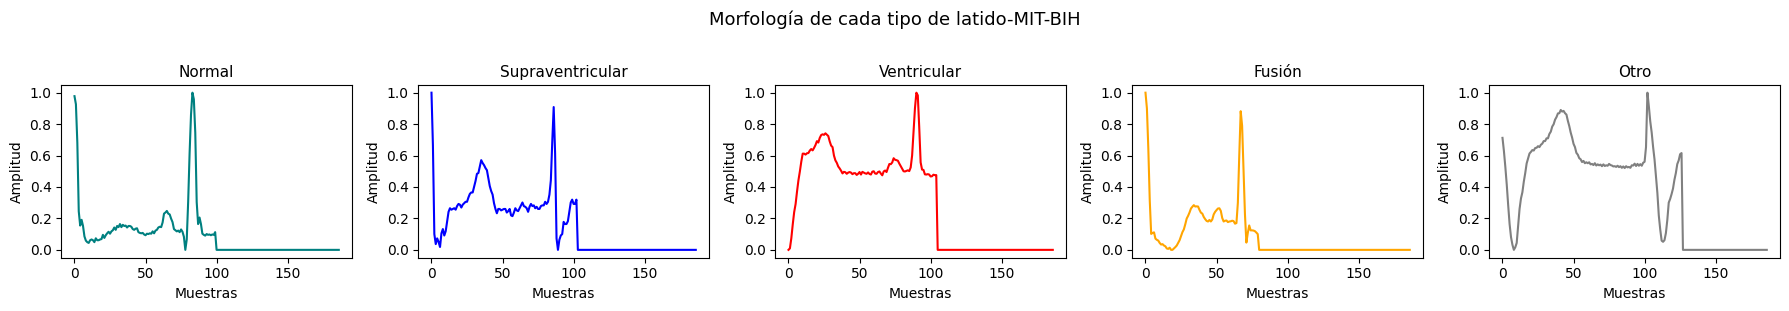

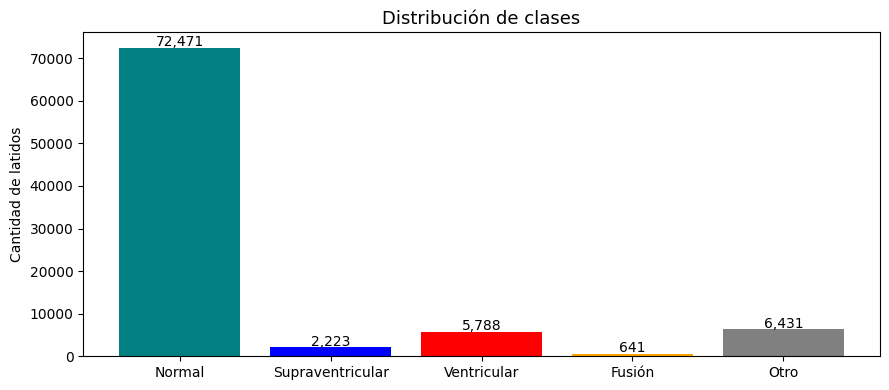

In [ ]:
# 5. VISUALIZACIÓN DE SEÑALES ECG
colores = {0:'teal', 1:'blue', 2:'red', 3:'orange', 4:'gray'}

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
fig.suptitle('Morfología de cada tipo de latido-MIT-BIH',
             fontsize=13, y=1.02)

for clase in range(5):
    idx    = y_train[y_train == clase].index[0]
    señal  = X_train.iloc[idx].values
    axes[clase].plot(señal, color=colores[clase], linewidth=1.5)
    axes[clase].set_title(nombres[float(clase)], fontsize=11)
    axes[clase].set_xlabel('Muestras')
    axes[clase].set_ylabel('Amplitud')

plt.tight_layout()
plt.show()

# Distribución visual
fig, ax = plt.subplots(figsize=(9, 4))
valores  = [conteo[float(i)] for i in range(5)]
etiquetas = [nombres[float(i)] for i in range(5)]
bars = ax.bar(etiquetas, valores,
              color=[colores[i] for i in range(5)])

ax.set_title('Distribución de clases', fontsize=13)
ax.set_ylabel('Cantidad de latidos')

for bar, val in zip(bars, valores):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+300,
            f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# 6. BALANCEO DE CLASES

analisis= round(100*72471/train.shape[0]) #Problema Dataset desbalanceado
print(analisis,"% de los datos son Normal")
print()

train_completo    = train.copy()
clases_balanceadas = []

for clase in sorted(y_train.unique()): #Detecta que clases existen
    subset = train_completo[train_completo.iloc[:, -1] == clase] #Filtra la fila de esa clase
    subset = subset.sample(n=min(5000, len(subset)), random_state=42)
    clases_balanceadas.append(subset)
    print(f"  Clase {clase:.0f}: {len(subset):,} muestras")

train_bal = pd.concat(clases_balanceadas).sample(frac=1, random_state=42) #Junta todos los subconjuntos, escoge todos los latidos de manera aleatoria
X_bal     = train_bal.iloc[:, :-1]
y_bal     = train_bal.iloc[:, -1]

print(f"\n  Total balanceado: {len(train_bal):,} latidos")


83 % de los datos son Normal

  Clase 0: 5,000 muestras
  Clase 1: 2,223 muestras
  Clase 2: 5,000 muestras
  Clase 3: 641 muestras
  Clase 4: 5,000 muestras

  Total balanceado: 17,864 latidos


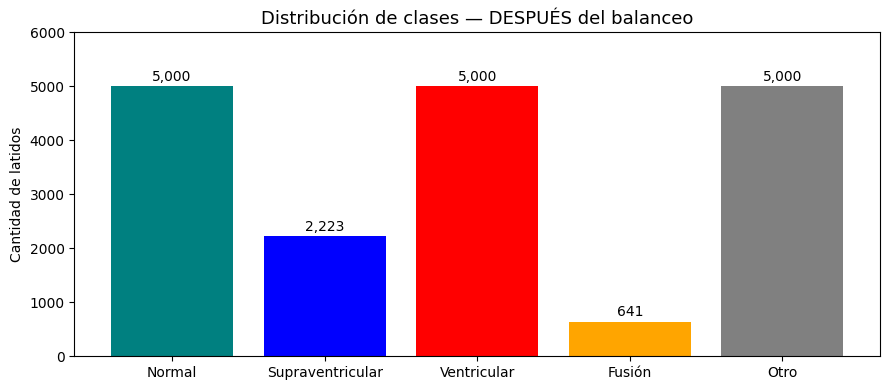

In [ ]:
# 7 Distribución visual DESPUÉS del balanceo
conteo_bal = y_bal.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
valores_bal = [conteo_bal[float(i)] for i in range(5)]
bars = ax.bar(etiquetas, valores_bal,
              color=[colores[i] for i in range(5)])

ax.set_title('Distribución de clases — DESPUÉS del balanceo', fontsize=13)
ax.set_ylabel('Cantidad de latidos')
ax.set_ylim(0, max(valores_bal) * 1.2)  # ahora usa los valores balanceados

for bar, val in zip(bars, valores_bal):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+100,
            f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Entrenamientos de modelo

In [ ]:
# Regresión Logistica
print("Entrenando modelo de Regresión Logística")
modelo_lr = LogisticRegression(max_iter=1000, random_state=42) #1000 para separar mejor los datos
modelo_lr.fit(X_bal, y_bal)   #puntos de se;al de cada latido y la respuesta correcta
y_pred_lr  = modelo_lr.predict(X_test) #Se prueba con los datos test
y_prob_lr  = modelo_lr.predict_proba(X_test)
loss_lr    = log_loss(y_test, y_prob_lr)
acc_lr     = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr:.1%}  |  Loss: {loss_lr:.4f}")

# Random Forest
print("\n Entrenando modelo de Random Forest")
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_bal, y_bal)
y_pred_rf  = modelo_rf.predict(X_test)
y_prob_rf  = modelo_rf.predict_proba(X_test)
loss_rf    = log_loss(y_test, y_prob_rf)
acc_rf     = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf:.1%}  |  Loss: {loss_rf:.4f}")

# Modelo 3: MLP (Red Neuronal)
print("\n Entrenando modelo de MLP")
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu', #Decide si la neurona se activa o no
    solver='adam', #Ajusta los pesos de las neuronas
    max_iter=50,
    random_state=42,
    verbose=False
)
modelo_mlp.fit(X_bal, y_bal)
y_pred_mlp  = modelo_mlp.predict(X_test)
y_prob_mlp  = modelo_mlp.predict_proba(X_test)
loss_mlp    = log_loss(y_test, y_prob_mlp)
acc_mlp     = accuracy_score(y_test, y_pred_mlp)
print(f"Accuracy: {acc_mlp:.1%}  |  Loss: {loss_mlp:.4f}")

Entrenando modelo de Regresión Logística
Accuracy: 78.4%  |  Loss: 0.6713

 Entrenando modelo de Random Forest
Accuracy: 95.6%  |  Loss: 0.2431

 Entrenando modelo de MLP
Accuracy: 93.3%  |  Loss: 0.2487


# Comparación Cuantitativa

In [ ]:
nombres_clases = ['Normal','Supraventricular','Ventricular','Fusión','Otro']
modelos_info = [
    ('Regresión Logística', y_pred_lr, y_prob_lr, acc_lr, loss_lr),
    ('Random Forest',       y_pred_rf, y_prob_rf, acc_rf, loss_rf),
    ('MLP',                 y_pred_mlp,y_prob_mlp,acc_mlp,loss_mlp),
]

# Reporte por modelo
for nombre, y_pred, _, acc, loss in modelos_info:
    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"  Accuracy: {acc:.1%}  |  Loss: {loss:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
          target_names=nombres_clases))

# Tabla comparativa
print("\n" + "="*65)
print("Comparación cuantitativa de los 3 modelos")
print("="*65)
print(f"{'Métrica':<22} {'Reg. Logística':>14} {'Random Forest':>14} {'MLP':>8}")
print("-"*65)

metricas = [
    ('Accuracy',  acc_lr,  acc_rf,  acc_mlp),
    ('Loss',      loss_lr, loss_rf, loss_mlp),
]
for nombre,v1,v2,v3 in metricas:
    print(f"  {nombre:<20} {v1:>13.1%} {v2:>13.1%} {v3:>7.1%}")

print("-"*65)
for i, clase in enumerate(nombres_clases):
    f1_lr_  = f1_score(y_test, y_pred_lr,  average=None)[i]
    f1_rf_  = f1_score(y_test, y_pred_rf,  average=None)[i]
    f1_mlp_ = f1_score(y_test, y_pred_mlp, average=None)[i]
    print(f"  {'F1 '+clase:<20} {f1_lr_:>13.1%} {f1_rf_:>13.1%} {f1_mlp_:>7.1%}")

print("-"*65)
f1_lr_m  = f1_score(y_test, y_pred_lr,  average='macro')
f1_rf_m  = f1_score(y_test, y_pred_rf,  average='macro')
f1_mlp_m = f1_score(y_test, y_pred_mlp, average='macro')
print(f"  {'F1 Macro':<20} {f1_lr_m:>13.1%} {f1_rf_m:>13.1%} {f1_mlp_m:>7.1%}")
print("="*65)
print(f"Mejor modelo: Random Forest ({acc_rf:.1%} accuracy)")


  Regresión Logística
  Accuracy: 78.4%  |  Loss: 0.6713
                  precision    recall  f1-score   support

          Normal       0.97      0.78      0.86     18118
Supraventricular       0.32      0.58      0.41       556
     Ventricular       0.30      0.81      0.44      1448
          Fusión       0.26      0.65      0.37       162
            Otro       0.74      0.91      0.82      1608

        accuracy                           0.78     21892
       macro avg       0.52      0.75      0.58     21892
    weighted avg       0.89      0.78      0.82     21892


  Random Forest
  Accuracy: 95.6%  |  Loss: 0.2431
                  precision    recall  f1-score   support

          Normal       0.99      0.96      0.98     18118
Supraventricular       0.62      0.78      0.69       556
     Ventricular       0.82      0.96      0.88      1448
          Fusión       0.59      0.77      0.67       162
            Otro       0.94      0.97      0.96      1608

        accurac

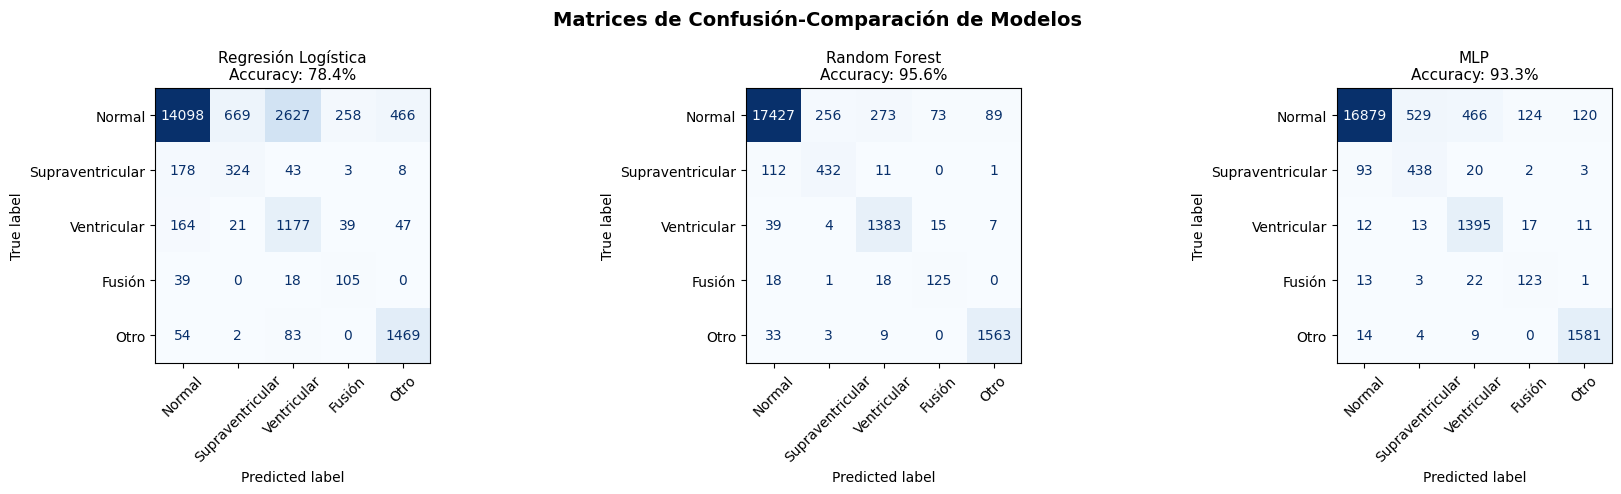

In [ ]:
# MATRICES DE CONFUSIÓN — 3 MODELOS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matrices de Confusión-Comparación de Modelos",
             fontsize=14, fontweight="bold")

for ax, (nombre, y_pred, _, acc, _) in zip(axes, modelos_info):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=nombres_clases)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{nombre}\nAccuracy: {acc:.1%}", fontsize=11)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

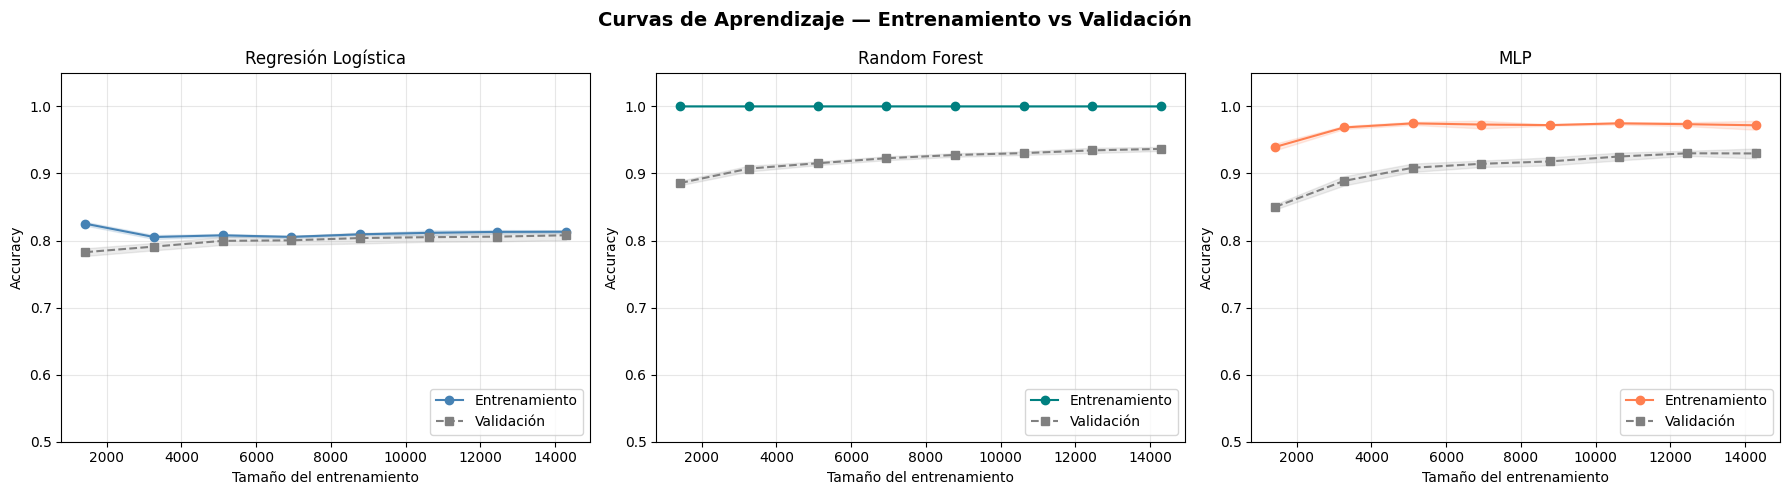

In [ ]:
# CURVAS DE APRENDIZAJE — Entrenamiento vs Validación
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curvas de Aprendizaje — Entrenamiento vs Validación',
             fontsize=14, fontweight='bold')

modelos_curva = [
    ('Regresión Logística', modelo_lr, 'steelblue'),
    ('Random Forest',       modelo_rf, 'teal'),
    ('MLP',                 modelo_mlp,'coral'),
]

for ax, (nombre, modelo, color) in zip(axes, modelos_curva):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_bal, y_bal,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores,  axis=1)
    val_mean   = np.mean(val_scores,   axis=1)
    val_std    = np.std(val_scores,    axis=1)

    # Línea de entrenamiento
    ax.plot(train_sizes, train_mean, 'o-', color=color,
            label='Entrenamiento')
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color=color)

    # Línea de validación
    ax.plot(train_sizes, val_mean, 's--', color='gray',
            label='Validación')
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color='gray')

    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel('Tamaño del entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.5, 1.05)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

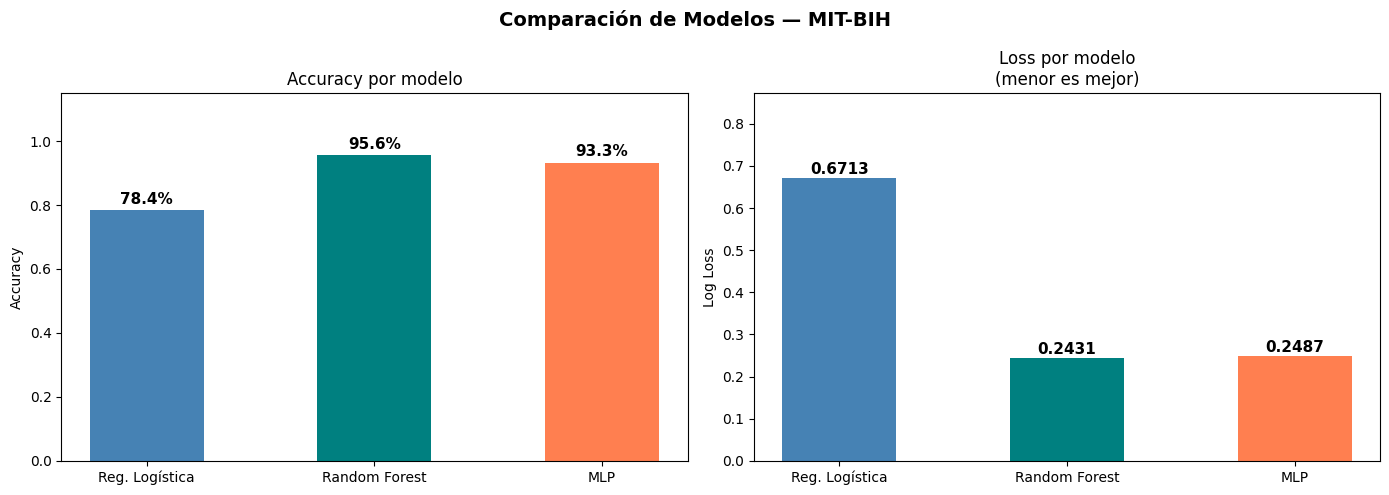

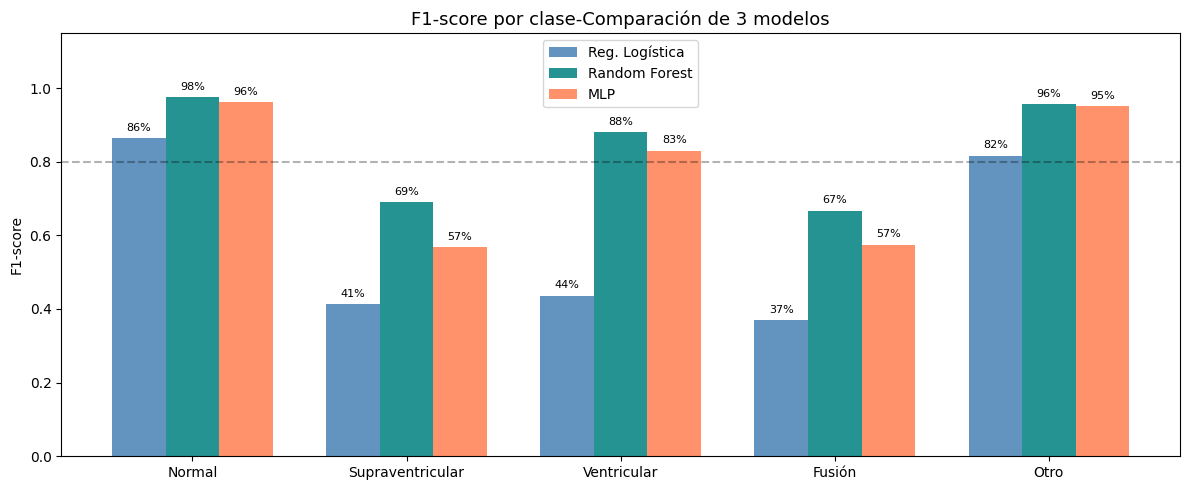

In [ ]:
# 8. COMPARACIÓN VISUAL DE MODELOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparación de Modelos — MIT-BIH",
             fontsize=14, fontweight="bold")

colores_mod = ["steelblue", "teal", "coral"]
modelo_names = ["Reg. Logística", "Random Forest", "MLP"]
x = np.arange(len(modelo_names))

# Accuracy y Loss
accuracies = [acc_lr,  acc_rf,  acc_mlp]
losses     = [loss_lr, loss_rf, loss_mlp]

bars = ax1.bar(x, accuracies, color=colores_mod, width=0.5)
ax1.set_title("Accuracy por modelo", fontsize=12)
ax1.set_ylabel("Accuracy")
ax1.set_xticks(x)
ax1.set_xticklabels(modelo_names)
ax1.set_ylim(0, 1.15)
for bar, val in zip(bars, accuracies):
    ax1.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.02,
             f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

bars2 = ax2.bar(x, losses, color=colores_mod, width=0.5)
ax2.set_title("Loss por modelo\n(menor es mejor)", fontsize=12)
ax2.set_ylabel("Log Loss")
ax2.set_xticks(x)
ax2.set_xticklabels(modelo_names)
ax2.set_ylim(0, max(losses)*1.3)
for bar, val in zip(bars2, losses):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.01,
             f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# ── F1 por clase ───────────────────────────────────────────
f1_lr_c  = f1_score(y_test, y_pred_lr,  average=None)
f1_rf_c  = f1_score(y_test, y_pred_rf,  average=None)
f1_mlp_c = f1_score(y_test, y_pred_mlp, average=None)

x2    = np.arange(len(nombres_clases))
ancho = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x2 - ancho, f1_lr_c,  ancho, label="Reg. Logística",
       color="steelblue", alpha=0.85)
ax.bar(x2,         f1_rf_c,  ancho, label="Random Forest",
       color="teal",      alpha=0.85)
ax.bar(x2 + ancho, f1_mlp_c, ancho, label="MLP",
       color="coral",     alpha=0.85)

ax.set_title("F1-score por clase-Comparación de 3 modelos", fontsize=13)
ax.set_ylabel("F1-score")
ax.set_xticks(x2)
ax.set_xticklabels(nombres_clases)
ax.set_ylim(0, 1.15)
ax.legend()
ax.axhline(y=0.8, color="black", linestyle="--", alpha=0.3)

for bars, f1s in [(ax.containers[0], f1_lr_c),
                   (ax.containers[1], f1_rf_c),
                   (ax.containers[2], f1_mlp_c)]:
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.02,
                f"{val:.0%}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

Dispositivo: cuda
GPU: Tesla T4

Train completo: torch.Size([17864, 187, 1])
Test:           torch.Size([21892, 187, 1])

── Transformer Pocos datos (5K, 10 épocas) ───────────────────────────
   Datos: 5,000 latidos | Épocas: 10
Época    Loss         Accuracy (test)
----------------------------------------
  1      1.5332       63.9%
  10     1.2886       51.1%

  ✅ Accuracy final: 51.1% | F1 Macro: 23.5%

── Transformer Datos completos (17K, 100 épocas) ───────────────────────────
   Datos: 17,864 latidos | Épocas: 100
Época    Loss         Accuracy (test)
----------------------------------------
  1      1.4080       53.9%
  10     0.7877       75.8%
  20     0.6432       71.3%
  30     0.5980       70.6%
  40     0.5338       75.7%
  50     0.4999       79.3%
  60     0.4695       76.1%
  70     0.4492       80.9%
  80     0.4327       75.2%
  90     0.4106       81.9%
  100    0.3997       79.9%

  ✅ Accuracy final: 79.9% | F1 Macro: 58.8%


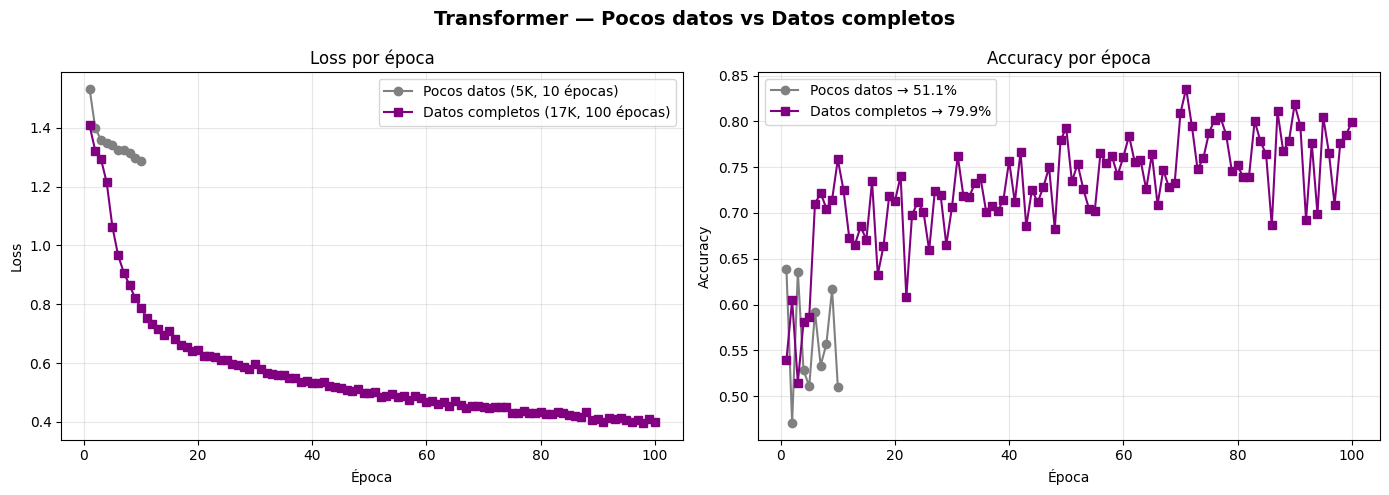


     COMPARACIÓN FINAL — 5 CONFIGURACIONES
Modelo                           Accuracy   F1 Macro       Loss
----------------------------------------------------------------------
  Regresión Logística              78.4%     58.0%     0.6713
  Random Forest                    95.6%     83.4%     0.2431
  MLP                              93.3%     77.7%     0.2487
  Transformer (5K, 10 épocas)      51.1%     23.5%        N/A
  Transformer (17K, 100 épocas)     79.9%     58.8%        N/A

🏆 Mejor modelo: Random Forest (95.6% accuracy)


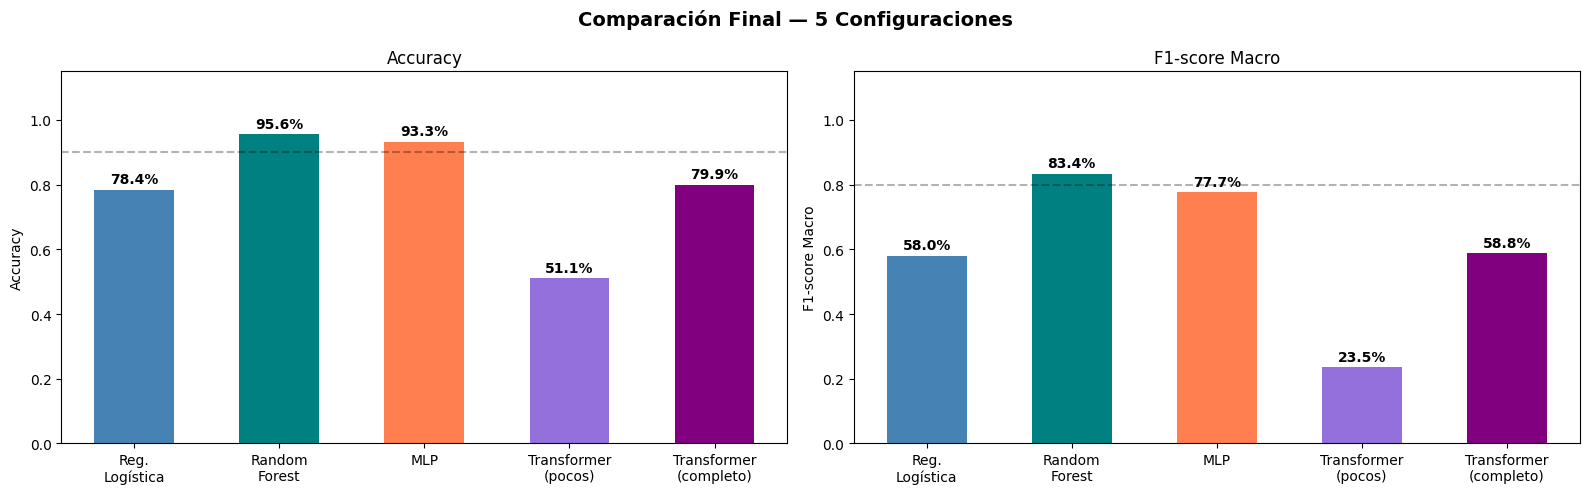


✅ modelo_tf listo para la demo — 79.9% accuracy


In [ ]:
# Transformer - Comparación entre muchos y pocos datos
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Semilla fija para reproducibilidad
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)

# Verificar GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No hay GPU — ve a Entorno de ejecución → GPU T4")

# Preparar datos
X_bal_np  = X_bal.values.astype('float32')
y_bal_np  = y_bal.values.astype('int64')
X_test_np = X_test.values.astype('float32')
y_test_np = y_test.values.astype('int64')

X_tr = torch.tensor(X_bal_np).unsqueeze(2)
y_tr = torch.tensor(y_bal_np)
X_te = torch.tensor(X_test_np).unsqueeze(2)
y_te = torch.tensor(y_test_np)

test_ds = TensorDataset(X_te, y_te)
test_dl = DataLoader(test_ds, batch_size=256)

print(f"\nTrain completo: {X_tr.shape}")
print(f"Test:           {X_te.shape}")

# Arquitectura
class ECGTransformer(nn.Module):
    def __init__(self, input_dim=1, d_model=64, nhead=4,
                 num_layers=2, num_classes=5):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=0.1,
            batch_first=True)
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)
        self.classifier  = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes))

    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

# Función de entrenamiento
def entrenar_transformer(X_data, y_data, epochs, batch_size, nombre):
    # Semilla fija dentro de la función también
    torch.manual_seed(42)

    modelo   = ECGTransformer().to(device)
    criterio = nn.CrossEntropyLoss()
    optimizer= torch.optim.Adam(modelo.parameters(), lr=0.001)

    ds = TensorDataset(X_data, y_data)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    print(f"\n Transformer {nombre} ")
    print(f"   Datos: {len(X_data):,} latidos | Épocas: {epochs}")
    print(f"{'Época':<8} {'Loss':<12} {'Accuracy (test)'}")
    print("-" * 40)

    hist_loss = []
    hist_acc  = []

    for epoch in range(epochs):
        modelo.train()
        loss_total = 0
        for Xb, yb in dl:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = modelo(Xb)
            loss = criterio(out, yb)
            loss.backward()
            optimizer.step()
            loss_total += loss.item()

        modelo.eval()
        preds_all = []
        with torch.no_grad():
            for Xb, yb in test_dl:
                Xb  = Xb.to(device)
                out = modelo(Xb)
                preds_all.extend(out.argmax(dim=1).cpu().numpy())

        loss_ep = loss_total / len(dl)
        acc_ep  = accuracy_score(y_test_np, np.array(preds_all))
        hist_loss.append(loss_ep)
        hist_acc.append(acc_ep)

        # Mostrar época 1 y luego cada 10
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"  {epoch+1:<6} {loss_ep:<12.4f} {acc_ep:.1%}")

    y_pred = np.array(preds_all)
    acc    = accuracy_score(y_test_np, y_pred)
    f1     = f1_score(y_test_np, y_pred, average='macro')
    print(f"\n Accuracy final: {acc:.1%} | F1 Macro: {f1:.1%}")

    return modelo, y_pred, acc, f1, hist_loss, hist_acc

# Prueba con Pocos datos
EPOCHS_POCO = 10
tf_poco, pred_poco, acc_poco, f1_poco, loss_poco, acc_h_poco = \
    entrenar_transformer(X_tr[:5000], y_tr[:5000],
                         epochs=EPOCHS_POCO, batch_size=256,
                         nombre="Pocos datos (5K, 10 épocas)")

# Prueba con Datos completos
EPOCHS_COMP = 100
tf_comp, pred_comp, acc_comp, f1_comp, loss_comp, acc_h_comp = \
    entrenar_transformer(X_tr, y_tr,
                         epochs=EPOCHS_COMP, batch_size=256,
                         nombre="Datos completos (17K, 100 épocas)")

# Gráfica comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transformer — Pocos datos vs Datos completos',
             fontsize=14, fontweight='bold')

ax1.plot(range(1, EPOCHS_POCO+1), loss_poco, 'o-', color='gray',
         label=f'Pocos datos (5K, {EPOCHS_POCO} épocas)')
ax1.plot(range(1, EPOCHS_COMP+1), loss_comp, 's-', color='purple',
         label=f'Datos completos (17K, {EPOCHS_COMP} épocas)')
ax1.set_title('Loss por época', fontsize=12)
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS_POCO+1), acc_h_poco, 'o-', color='gray',
         label=f'Pocos datos → {acc_poco:.1%}')
ax2.plot(range(1, EPOCHS_COMP+1), acc_h_comp, 's-', color='purple',
         label=f'Datos completos → {acc_comp:.1%}')
ax2.set_title('Accuracy por época', fontsize=12)
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla comparativa
f1_lr_m  = f1_score(y_test, y_pred_lr,  average='macro')
f1_rf_m  = f1_score(y_test, y_pred_rf,  average='macro')
f1_mlp_m = f1_score(y_test, y_pred_mlp, average='macro')

print("\n" + "="*70)
print("     COMPARACIÓN FINAL — 5 CONFIGURACIONES")
print("="*70)
print(f"{'Modelo':<30} {'Accuracy':>10} {'F1 Macro':>10} {'Loss':>10}")
print("-"*70)

modelos_final = [
    ('Regresión Logística',           acc_lr,   f1_lr_m,  loss_lr),
    ('Random Forest',                 acc_rf,   f1_rf_m,  loss_rf),
    ('MLP',                           acc_mlp,  f1_mlp_m, loss_mlp),
    ('Transformer (5K, 10 épocas)',   acc_poco, f1_poco,  None),
    ('Transformer (17K, 100 épocas)', acc_comp, f1_comp,  None),
]
for nombre, acc, f1, loss in modelos_final:
    loss_str = f'{loss:.4f}' if loss else '  N/A'
    print(f"  {nombre:<28} {acc:>9.1%} {f1:>9.1%} {loss_str:>10}")

print("="*70)
mejor = max(modelos_final, key=lambda x: x[1])
print(f"\n Mejor modelo: {mejor[0]} ({mejor[1]:.1%} accuracy)")

# Gráfica final
nombres_mod = ['Reg.\nLogística', 'Random\nForest', 'MLP',
               'Transformer\n(pocos)', 'Transformer\n(completo)']
accs = [acc_lr,  acc_rf,  acc_mlp, acc_poco, acc_comp]
f1s  = [f1_lr_m, f1_rf_m, f1_mlp_m, f1_poco, f1_comp]
cols = ['steelblue', 'teal', 'coral', 'mediumpurple', 'purple']
x    = np.arange(len(nombres_mod))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparación Final — 5 Configuraciones',
             fontsize=14, fontweight='bold')

for ax, vals, titulo in [(ax1, accs, 'Accuracy'),
                          (ax2, f1s,  'F1-score Macro')]:
    bars = ax.bar(x, vals, color=cols, width=0.55)
    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel(titulo)
    ax.set_xticks(x)
    ax.set_xticklabels(nombres_mod, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.axhline(y=0.9 if titulo=='Accuracy' else 0.8,
               color='black', linestyle='--', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.02,
                f'{val:.1%}', ha='center',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Guardamos el mejor Transformer para la demo
modelo_tf = tf_comp  # usamos el completo para la demo
acc_tf    = acc_comp
f1_tf     = f1_comp
y_pred_tf = pred_comp
print(f"\n modelo_tf listo para la demo — {acc_tf:.1%} accuracy")

DEMO — Clasificador de Arritmias Cardíacas
  1. Sube un archivo CSV con 187 valores
  2. Se analiza el archivo antes de predecir
  3. Los 3 modelos predicen el tipo de latido


Saving demo_ventricular.csv to demo_ventricular (2).csv

 Análisis del archivo: demo_ventricular (2).csv
  Número de valores:     187 puntos de señal
  Valor mínimo:          0.0000
  Valor máximo:          1.0000
  Valor promedio:        0.1340
  Desviación estándar:   0.2736
  Frecuencia muestreo:   360 Hz (MIT-BIH estándar)
  Duración del latido:   519.4 ms aprox.


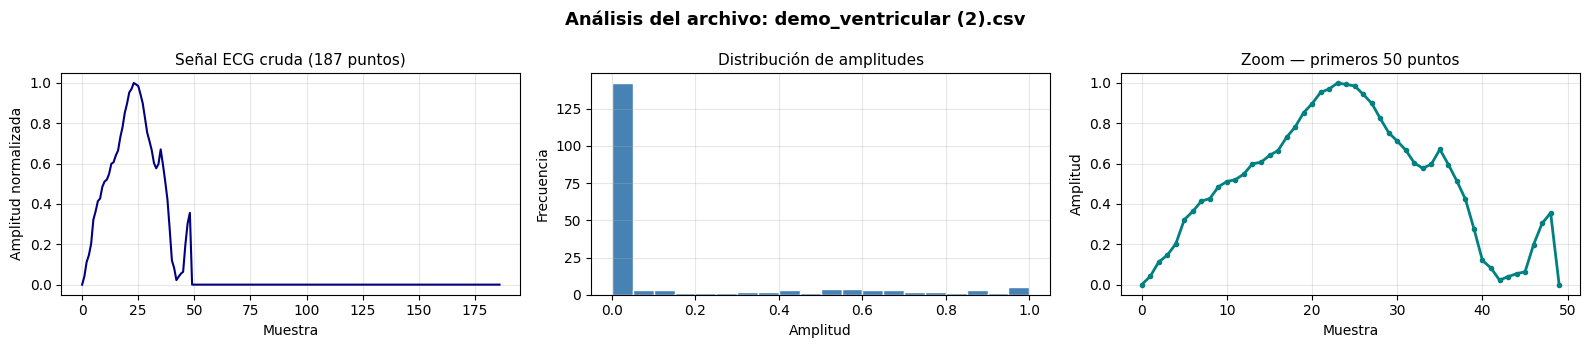


  Este archivo contiene UN latido cardíaco segmentado
  en 187 muestras a 360 Hz — formato estándar MIT-BIH.
  Los valores están normalizados entre 0 y 1.


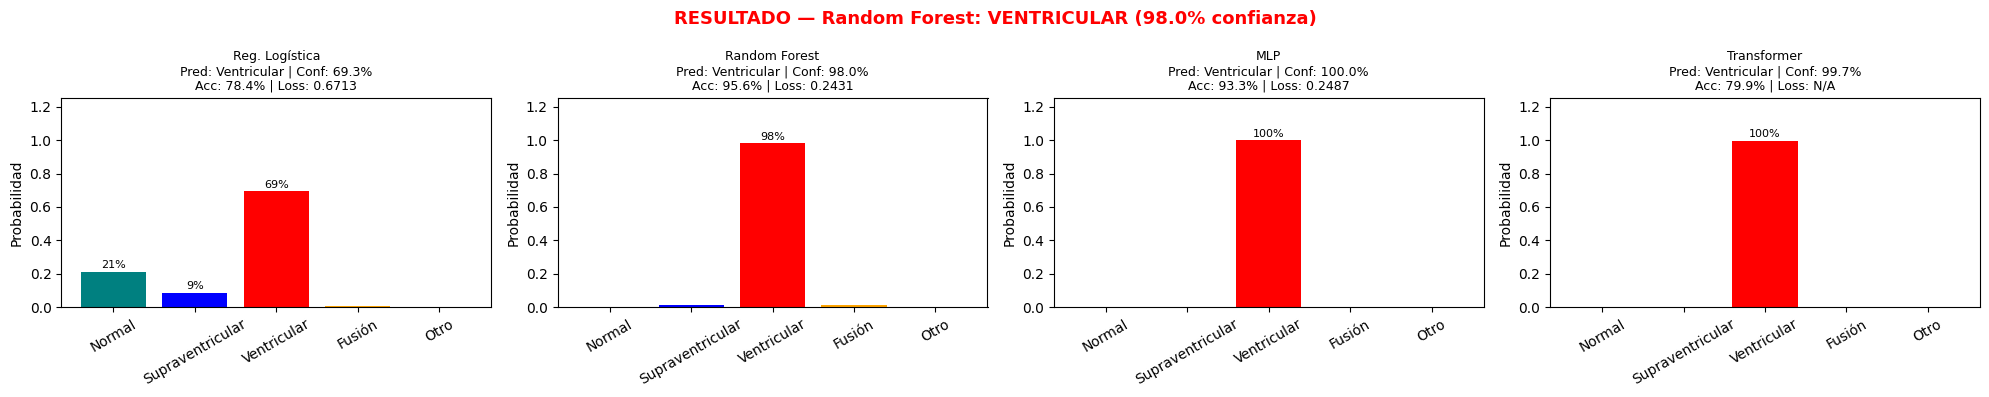


── Resumen de predicciones ───────────────────────────
  Modelo                 Predicción            Confianza   Accuracy     Loss
  ---------------------------------------------------------------------------
  Reg. Logística         Ventricular               69.3%     78.4%   0.6713
  Random Forest          Ventricular               98.0%     95.6%   0.2431
  MLP                    Ventricular              100.0%     93.3%   0.2487
  Transformer            Ventricular               99.7%     79.9%      N/A

  Riesgo clínico:   ⚠️ ALTO
  ¿Los 4 coinciden? ✅ SÍ


In [ ]:
# 9. DEMO EN VIVO — PREDICCIÓN DE LATIDO INDIVIDUAL
print("DEMO — Clasificador de Arritmias Cardíacas")
print("=" * 55)
print("  1. Sube un archivo CSV con 187 valores")
print("  2. Se analiza el archivo antes de predecir")
print("  3. Los 3 modelos predicen el tipo de latido")
print("=" * 55)

uploaded = files.upload()

for nombre_archivo, contenido in uploaded.items():

    # Leer CSV
    latido = pd.read_csv(io.BytesIO(contenido),
                         header=None).values.flatten()
    latido = latido[:187].reshape(1, -1)
    señal  = latido.flatten()

    # PARTE 1 — ¿QUÉ ES EL ARCHIVO QUE SUBIMOS?
    print(f"\n Análisis del archivo: {nombre_archivo}")
    print(f"  Número de valores:     {len(señal)} puntos de señal")
    print(f"  Valor mínimo:          {señal.min():.4f}")
    print(f"  Valor máximo:          {señal.max():.4f}")
    print(f"  Valor promedio:        {señal.mean():.4f}")
    print(f"  Desviación estándar:   {señal.std():.4f}")
    print(f"  Frecuencia muestreo:   360 Hz (MIT-BIH estándar)")
    print(f"  Duración del latido:   {len(señal)/360*1000:.1f} ms aprox.")

    # Gráfica del archivo crudo
    fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
    fig.suptitle(f'Análisis del archivo: {nombre_archivo}',
                 fontsize=13, fontweight='bold')

    # Señal completa
    axes[0].plot(señal, color='navy', linewidth=1.5)
    axes[0].set_title('Señal ECG cruda (187 puntos)', fontsize=11)
    axes[0].set_xlabel('Muestra')
    axes[0].set_ylabel('Amplitud normalizada')
    axes[0].grid(True, alpha=0.3)

    # Histograma de amplitudes
    axes[1].hist(señal, bins=20, color='steelblue', edgecolor='white')
    axes[1].set_title('Distribución de amplitudes', fontsize=11)
    axes[1].set_xlabel('Amplitud')
    axes[1].set_ylabel('Frecuencia')
    axes[1].grid(True, alpha=0.3)

    # Primeros 50 puntos zoom
    axes[2].plot(señal[:50], color='teal', linewidth=2, marker='o',
                 markersize=3)
    axes[2].set_title('Zoom — primeros 50 puntos', fontsize=11)
    axes[2].set_xlabel('Muestra')
    axes[2].set_ylabel('Amplitud')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n  Este archivo contiene UN latido cardíaco segmentado")
    print("  en 187 muestras a 360 Hz — formato estándar MIT-BIH.")
    print("  Los valores están normalizados entre 0 y 1.")

    # Predicciones de los 4 modelos incluyendo Transformer
pred_lr  = int(modelo_lr.predict(latido)[0])
pred_rf  = int(modelo_rf.predict(latido)[0])
pred_mlp = int(modelo_mlp.predict(latido)[0])

# Transformer — necesita formato tensor
latido_tensor = torch.tensor(
    latido.astype('float32')).unsqueeze(2).to(device)
modelo_tf.eval()
with torch.no_grad():
    output_tf = modelo_tf(latido_tensor)
    pred_tf   = int(output_tf.argmax(dim=1).cpu().numpy()[0])
    prob_tf   = torch.softmax(output_tf, dim=1).cpu().numpy()[0]

prob_lr  = modelo_lr.predict_proba(latido)[0]
prob_rf  = modelo_rf.predict_proba(latido)[0]
prob_mlp = modelo_mlp.predict_proba(latido)[0]

confianza_lr  = prob_lr[pred_lr]   * 100
confianza_rf  = prob_rf[pred_rf]   * 100
confianza_mlp = prob_mlp[pred_mlp] * 100
confianza_tf  = prob_tf[pred_tf]   * 100

nombres_pred = {0:'Normal', 1:'Supraventricular',
                2:'Ventricular', 3:'Fusión', 4:'Otro'}
colores_pred = {0:'teal', 1:'blue', 2:'red', 3:'orange', 4:'gray'}

# Gráfica de los 4 modelos
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(
    f'RESULTADO — Random Forest: {nombres_pred[pred_rf].upper()} '
    f'({confianza_rf:.1f}% confianza)',
    fontsize=13, fontweight='bold',
    color=colores_pred[pred_rf]
)

for ax, (nombre, pred, prob, acc, loss) in zip(axes, [
    ('Reg. Logística', pred_lr,  prob_lr,  acc_lr,  loss_lr),
    ('Random Forest',  pred_rf,  prob_rf,  acc_rf,  loss_rf),
    ('MLP',            pred_mlp, prob_mlp, acc_mlp, loss_mlp),
    ('Transformer',    pred_tf,  prob_tf,  acc_tf,  None),
]):
    bars = ax.bar(list(nombres_pred.values()), prob,
                  color=list(colores_pred.values()))
    loss_str = f'{loss:.4f}' if loss else 'N/A'
    ax.set_title(
        f'{nombre}\n'
        f'Pred: {nombres_pred[pred]} | '
        f'Conf: {prob[pred]*100:.1f}%\n'
        f'Acc: {acc:.1%} | Loss: {loss_str}',
        fontsize=9
    )
    ax.set_ylabel('Probabilidad')
    ax.set_ylim(0, 1.25)
    ax.tick_params(axis='x', rotation=30)
    for bar, p in zip(bars, prob):
        if p > 0.02:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.02,
                    f'{p:.0%}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# Resumen final
print(f"\n Resumen de predicciones")
print(f"  {'Modelo':<22} {'Predicción':<20} {'Confianza':>10} {'Accuracy':>10} {'Loss':>8}")
print(f"  {'-'*75}")
print(f"  {'Reg. Logística':<22} {nombres_pred[pred_lr]:<20} {confianza_lr:>9.1f}% {acc_lr:>9.1%} {loss_lr:>8.4f}")
print(f"  {'Random Forest':<22} {nombres_pred[pred_rf]:<20} {confianza_rf:>9.1f}% {acc_rf:>9.1%} {loss_rf:>8.4f}")
print(f"  {'MLP':<22} {nombres_pred[pred_mlp]:<20} {confianza_mlp:>9.1f}% {acc_mlp:>9.1%} {loss_mlp:>8.4f}")
print(f"  {'Transformer':<22} {nombres_pred[pred_tf]:<20} {confianza_tf:>9.1f}% {acc_tf:>9.1%} {'N/A':>8}")
print(f"\n  Riesgo clínico:   {'ALTO' if pred_rf == 2 else 'BAJO'}")
print(f"  ¿Los 4 coinciden? {'SÍ' if pred_lr==pred_rf==pred_mlp==pred_tf else '⚠️ NO — los modelos difieren'}")